# **Tugas Besar: Analitik Prediktif dalam CRM Logistik**

**Kasus 15 – Prediksi Ketepatan Pembayaran Kartu Kredit**

**Dataset:** Default of Credit Card Clients (UCI Machine Learning Repository)

**Target:**  (1 = terlambat/default, 0 = tepat waktu)

**Model:** Logistic Regression · Decision Tree · Artificial Neural Network (ANN/BPNN)

---

# **Early Step**

### Import Library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import (
    train_test_split, GridSearchCV,
    KFold, StratifiedKFold, LeaveOneOut, cross_val_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, roc_curve
)
from imblearn.over_sampling import SMOTE

print("Libraries imported successfully!")

Libraries imported successfully!


### Import Dataset

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving UCI_Credit_Card.csv to UCI_Credit_Card.csv


In [ ]:
import io
df = pd.read_csv(io.BytesIO(uploaded["UCI_Credit_Card.csv"]))
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


---
# **Exploratory Data Analysis (EDA)**

### Data Shape & Info

In [ ]:
print(f"Shape dataset: {df.shape}")
print(f"Jumlah baris: {df.shape[0]}, Jumlah kolom: {df.shape[1]}")
print("\nTipe data setiap kolom:")
df.info()

Shape dataset: (30000, 25)
Jumlah baris: 30000, Jumlah kolom: 25

Tipe data setiap kolom:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12

### Descriptive Statistics

In [ ]:
df.describe()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


### Missing Values Check

In [ ]:
missing = df.isnull().sum()
print("Missing values per kolom:")
print(missing[missing > 0] if missing.sum() > 0 else "Tidak ada missing values!")
print(f"Total missing values: {df.isnull().sum().sum()}")

Missing values per kolom:
Tidak ada missing values!
Total missing values: 0


### Target Class Distribution

Distribusi Target Variable:
default.payment.next.month
0    23364
1     6636
Name: count, dtype: int64
Proporsi (%):
default.payment.next.month
0    77.88
1    22.12
Name: proportion, dtype: float64


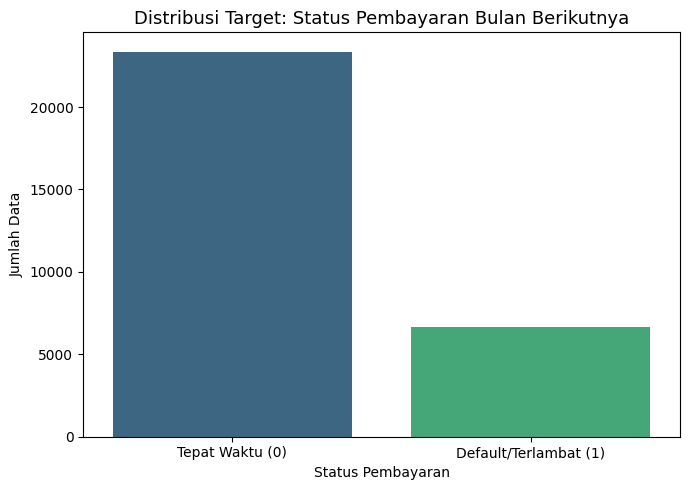

In [ ]:
print("Distribusi Target Variable:")
print(df["default.payment.next.month"].value_counts())
print(f"Proporsi (%):\n{df["default.payment.next.month"].value_counts(normalize=True).mul(100).round(2)}")

plt.figure(figsize=(7, 5))
sns.countplot(x="default.payment.next.month", data=df,
              hue="default.payment.next.month", palette="viridis", legend=False)
plt.title("Distribusi Target: Status Pembayaran Bulan Berikutnya", fontsize=13)
plt.xlabel("Status Pembayaran")
plt.ylabel("Jumlah Data")
plt.xticks(ticks=[0, 1], labels=["Tepat Waktu (0)", "Default/Terlambat (1)"])
plt.tight_layout()
plt.show()

### Distribusi Fitur Numerik Utama

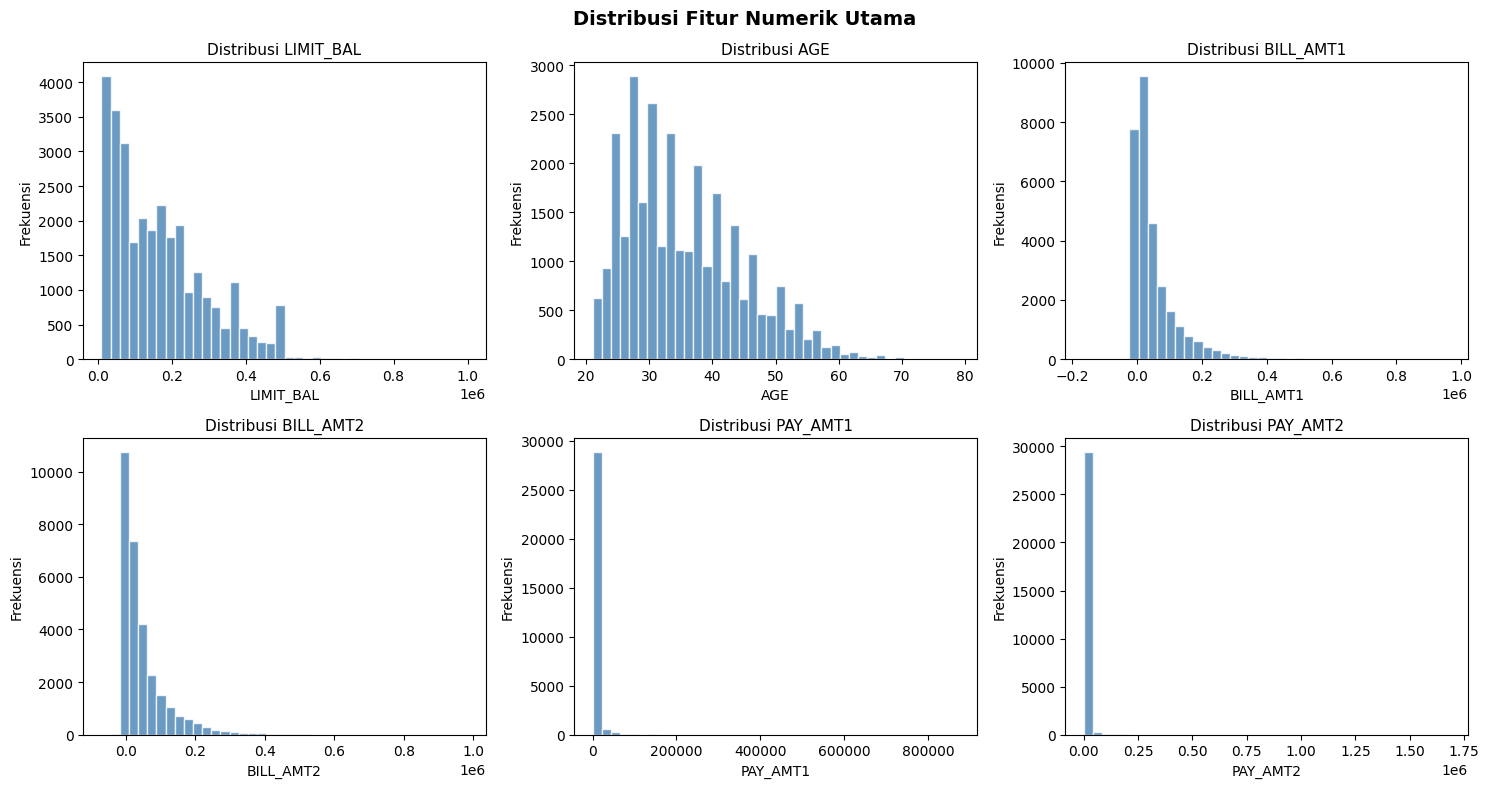

In [ ]:
num_features = ["LIMIT_BAL", "AGE", "BILL_AMT1", "BILL_AMT2", "PAY_AMT1", "PAY_AMT2"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(num_features):
    axes[i].hist(df[col], bins=40, color="steelblue", edgecolor="white", alpha=0.8)
    axes[i].set_title(f"Distribusi {col}", fontsize=11)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frekuensi")

plt.suptitle("Distribusi Fitur Numerik Utama", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### Fitur Kategorik: SEX, EDUCATION, MARRIAGE

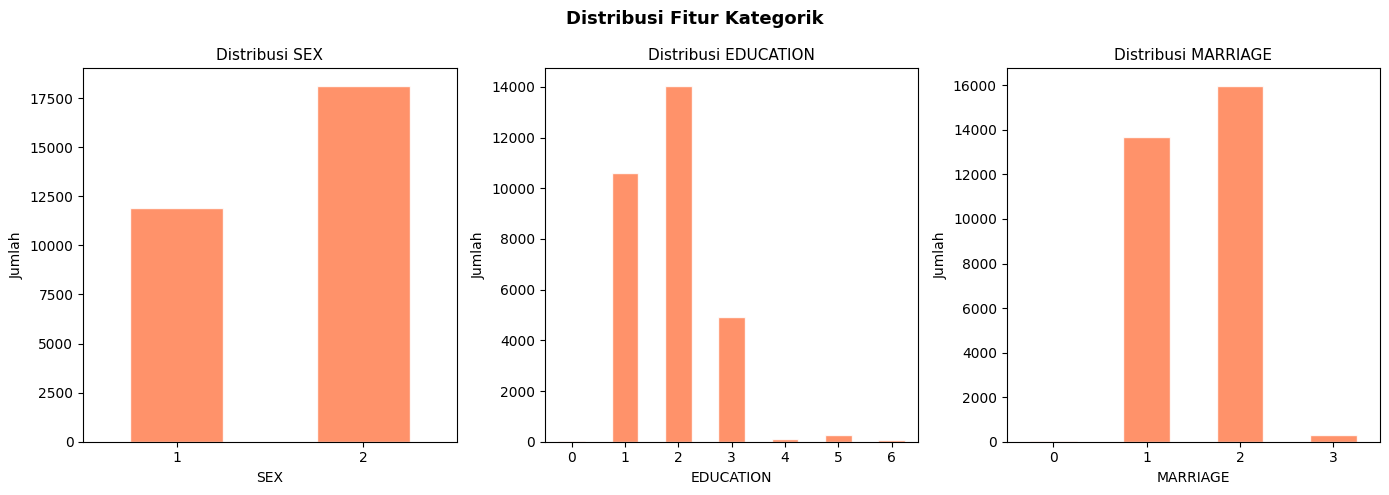

In [ ]:
cat_features = ["SEX", "EDUCATION", "MARRIAGE"]
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for i, col in enumerate(cat_features):
    df[col].value_counts().sort_index().plot(kind="bar", ax=axes[i],
        color="coral", edgecolor="white", alpha=0.85)
    axes[i].set_title(f"Distribusi {col}", fontsize=11)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Jumlah")
    axes[i].tick_params(axis="x", rotation=0)

plt.suptitle("Distribusi Fitur Kategorik", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### Feature Correlation Heatmap

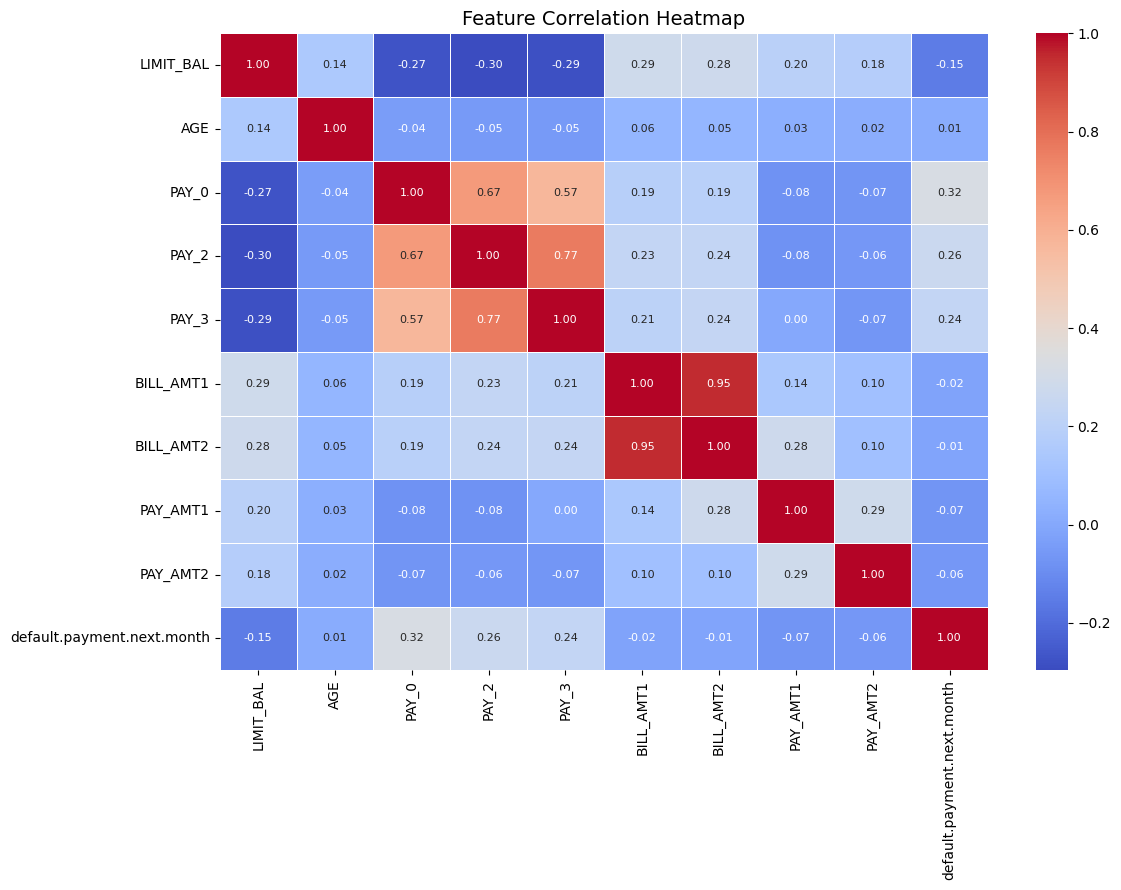

In [ ]:
corr_cols = ["LIMIT_BAL", "AGE", "PAY_0", "PAY_2", "PAY_3",
             "BILL_AMT1", "BILL_AMT2", "PAY_AMT1", "PAY_AMT2",
             "default.payment.next.month"]

plt.figure(figsize=(12, 9))
sns.heatmap(df[corr_cols].corr(), annot=True, fmt=".2f",
            cmap="coolwarm", linewidths=0.5, annot_kws={"size": 8})
plt.title("Feature Correlation Heatmap", fontsize=14)
plt.tight_layout()
plt.show()

### Boxplot: LIMIT_BAL vs Default Status

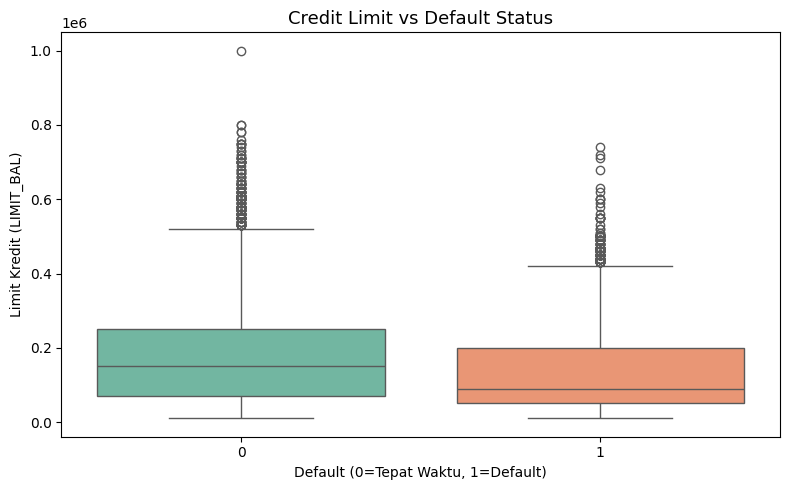

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="default.payment.next.month", y="LIMIT_BAL", data=df,
            hue="default.payment.next.month", palette="Set2", legend=False)
plt.title("Credit Limit vs Default Status", fontsize=13)
plt.xlabel("Default (0=Tepat Waktu, 1=Default)")
plt.ylabel("Limit Kredit (LIMIT_BAL)")
plt.tight_layout()
plt.show()

---
# **Data Preprocessing**

### Anonimisasi & Drop Kolom Tidak Relevan

In [ ]:
# Hapus kolom ID (data pribadi/identifikasi - anonimisasi)
df = df.drop(columns=["ID"])
print(f"Kolom ID telah dihapus. Shape sekarang: {df.shape}")

# Standarisasi nilai tidak valid pada EDUCATION dan MARRIAGE
# EDUCATION: 0, 5, 6 -> gabungkan ke kategori Other (4)
df["EDUCATION"] = df["EDUCATION"].replace({0: 4, 5: 4, 6: 4})

# MARRIAGE: 0 -> gabungkan ke Other (3)
df["MARRIAGE"] = df["MARRIAGE"].replace({0: 3})

print("Nilai unik EDUCATION:", sorted(df["EDUCATION"].unique()))
print("Nilai unik MARRIAGE:", sorted(df["MARRIAGE"].unique()))

Kolom ID telah dihapus. Shape sekarang: (30000, 24)
Nilai unik EDUCATION: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Nilai unik MARRIAGE: [np.int64(1), np.int64(2), np.int64(3)]


### Feature & Target Split

In [ ]:
X = df.drop(columns=["default.payment.next.month"])
y = df["default.payment.next.month"]

print(f"Shape fitur (X): {X.shape}")
print(f"Shape target (y): {y.shape}")
print(f"\nFitur yang digunakan:\n{X.columns.tolist()}")

Shape fitur (X): (30000, 23)
Shape target (y): (30000,)

Fitur yang digunakan:
['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']


### Train-Test Split (80:20)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {X_train.shape[0]} data ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Test size : {X_test.shape[0]} data ({X_test.shape[0]/len(X)*100:.1f}%)")

Train size: 24000 data (80.0%)
Test size : 6000 data (20.0%)


### Class Distribution Before SMOTE

Distribusi kelas sebelum SMOTE:
default.payment.next.month
0    18691
1     5309
Name: count, dtype: int64


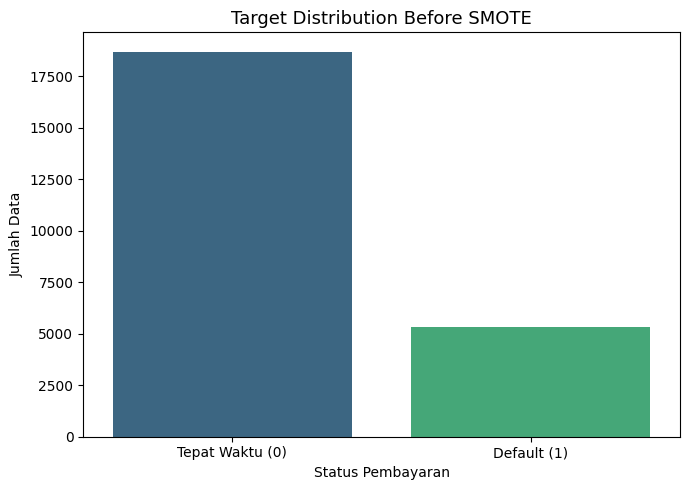

In [ ]:
print("Distribusi kelas sebelum SMOTE:")
print(y_train.value_counts())

plt.figure(figsize=(7, 5))
sns.countplot(x=y_train, hue=y_train, palette="viridis", legend=False)
plt.title("Target Distribution Before SMOTE", fontsize=13)
plt.xlabel("Status Pembayaran")
plt.ylabel("Jumlah Data")
plt.xticks(ticks=[0, 1], labels=["Tepat Waktu (0)", "Default (1)"])
plt.tight_layout()
plt.show()

### Oversampling Using SMOTE

In [ ]:
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)
print("SMOTE selesai!")

SMOTE selesai!


### Class Distribution After SMOTE

Distribusi kelas setelah SMOTE:
default.payment.next.month
0    18691
1    18691
Name: count, dtype: int64


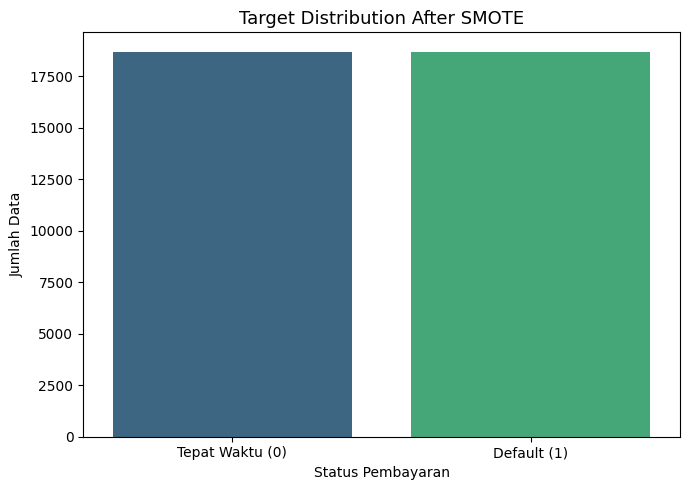

In [ ]:
print("Distribusi kelas setelah SMOTE:")
print(pd.Series(y_train).value_counts())

plt.figure(figsize=(7, 5))
sns.countplot(x=y_train, hue=y_train, palette="viridis", legend=False)
plt.title("Target Distribution After SMOTE", fontsize=13)
plt.xlabel("Status Pembayaran")
plt.ylabel("Jumlah Data")
plt.xticks(ticks=[0, 1], labels=["Tepat Waktu (0)", "Default (1)"])
plt.tight_layout()
plt.show()

---
# **Model 1: Logistic Regression**

### Hyperparameter Tuning (GridSearchCV)

In [ ]:
lr_model = LogisticRegression(random_state=42, max_iter=1000)

param_grid_lr = {
    "C": [0.01, 0.1, 1, 10, 100],
    "solver": ["liblinear", "lbfgs"],
    "penalty": ["l2"]
}

grid_search_lr = GridSearchCV(
    estimator=lr_model,
    param_grid=param_grid_lr,
    cv=5,
    scoring="roc_auc",
    verbose=1,
    n_jobs=-1
)

# Scale fitur sebelum training LR
scaler_lr = StandardScaler()
X_train_sc = scaler_lr.fit_transform(X_train)
X_test_sc  = scaler_lr.transform(X_test)

grid_search_lr.fit(X_train_sc, y_train)

best_lr = grid_search_lr.best_estimator_
print("Best Parameters from GridSearch:")
print(grid_search_lr.best_params_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best Parameters from GridSearch:
{'C': 100, 'penalty': 'l2', 'solver': 'lbfgs'}


### Logistic Regression – Evaluasi Model

In [ ]:
y_pred_lr   = best_lr.predict(X_test_sc)
y_prob_lr   = best_lr.predict_proba(X_test_sc)[:, 1]

acc_lr  = accuracy_score(y_test, y_pred_lr)
f1_lr   = f1_score(y_test, y_pred_lr)
auc_lr  = roc_auc_score(y_test, y_prob_lr)

print("=== Logistic Regression – Model Evaluation ===")
print(f"Accuracy  : {acc_lr:.4f}")
print(f"F1-Score  : {f1_lr:.4f}")
print(f"ROC-AUC   : {auc_lr:.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_lr,
      target_names=["Tepat Waktu (0)", "Default (1)"]))

=== Logistic Regression – Model Evaluation ===
Accuracy  : 0.6898
F1-Score  : 0.4531
ROC-AUC   : 0.6914
Classification Report:
                 precision    recall  f1-score   support

Tepat Waktu (0)       0.86      0.72      0.78      4673
    Default (1)       0.37      0.58      0.45      1327

       accuracy                           0.69      6000
      macro avg       0.61      0.65      0.62      6000
   weighted avg       0.75      0.69      0.71      6000



### Confusion Matrix – Logistic Regression

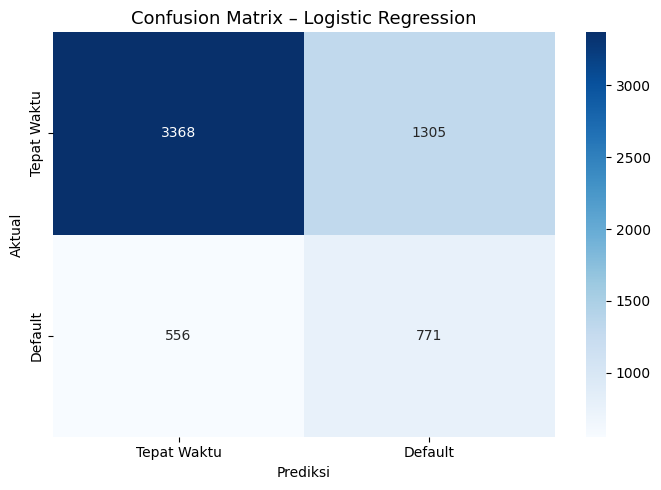

In [ ]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Tepat Waktu", "Default"],
            yticklabels=["Tepat Waktu", "Default"])
plt.title("Confusion Matrix – Logistic Regression", fontsize=13)
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.tight_layout()
plt.show()

### ROC Curve – Logistic Regression

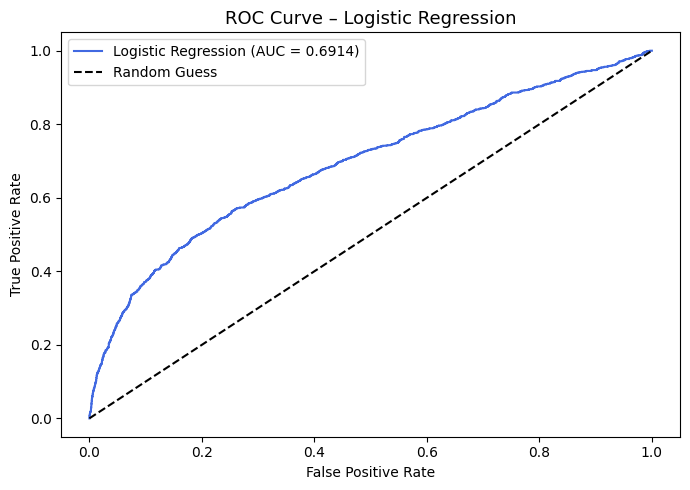

In [ ]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)

plt.figure(figsize=(7, 5))
plt.plot(fpr_lr, tpr_lr, color="royalblue",
         label=f"Logistic Regression (AUC = {auc_lr:.4f})")
plt.plot([0, 1], [0, 1], "k--", label="Random Guess")
plt.title("ROC Curve – Logistic Regression", fontsize=13)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

---
# **Model 2: Decision Tree**

### Decision Tree Pipeline & Hyperparameter Tuning

In [ ]:
dt_pipe = make_pipeline(
    StandardScaler(),
    DecisionTreeClassifier(random_state=42, class_weight="balanced")
)

param_grid_dt = {
    "decisiontreeclassifier__criterion": ["gini", "entropy"],
    "decisiontreeclassifier__max_depth": [5, 10, 15, 20, None],
    "decisiontreeclassifier__min_samples_split": [2, 5, 10],
    "decisiontreeclassifier__min_samples_leaf": [1, 5, 10, 20],
    "decisiontreeclassifier__ccp_alpha": [0.0, 0.001, 0.01]
}

grid_search_dt = GridSearchCV(
    dt_pipe,
    param_grid=param_grid_dt,
    cv=5,
    scoring="accuracy",
    verbose=1,
    n_jobs=-1
)
grid_search_dt.fit(X_train, y_train)
best_dt = grid_search_dt.best_estimator_

print("Best Hyperparameters (Decision Tree):")
print(grid_search_dt.best_params_)

Fitting 5 folds for each of 360 candidates, totalling 1800 fits
Best Hyperparameters (Decision Tree):
{'decisiontreeclassifier__ccp_alpha': 0.0, 'decisiontreeclassifier__criterion': 'entropy', 'decisiontreeclassifier__max_depth': None, 'decisiontreeclassifier__min_samples_leaf': 1, 'decisiontreeclassifier__min_samples_split': 2}


### Decision Tree – Evaluasi Model

In [ ]:
y_pred_dt  = best_dt.predict(X_test)
y_prob_dt  = best_dt.predict_proba(X_test)[:, 1]

acc_dt  = accuracy_score(y_test, y_pred_dt)
f1_dt   = f1_score(y_test, y_pred_dt)
auc_dt  = roc_auc_score(y_test, y_prob_dt)

print("=== Decision Tree – Model Evaluation ===")
print(f"Accuracy  : {acc_dt:.4f}")
print(f"F1-Score  : {f1_dt:.4f}")
print(f"ROC-AUC   : {auc_dt:.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_dt,
      target_names=["Tepat Waktu (0)", "Default (1)"]))

=== Decision Tree – Model Evaluation ===
Accuracy  : 0.6977
F1-Score  : 0.4103
ROC-AUC   : 0.6186
Classification Report:
                 precision    recall  f1-score   support

Tepat Waktu (0)       0.84      0.76      0.80      4673
    Default (1)       0.36      0.48      0.41      1327

       accuracy                           0.70      6000
      macro avg       0.60      0.62      0.60      6000
   weighted avg       0.73      0.70      0.71      6000



### Confusion Matrix – Decision Tree

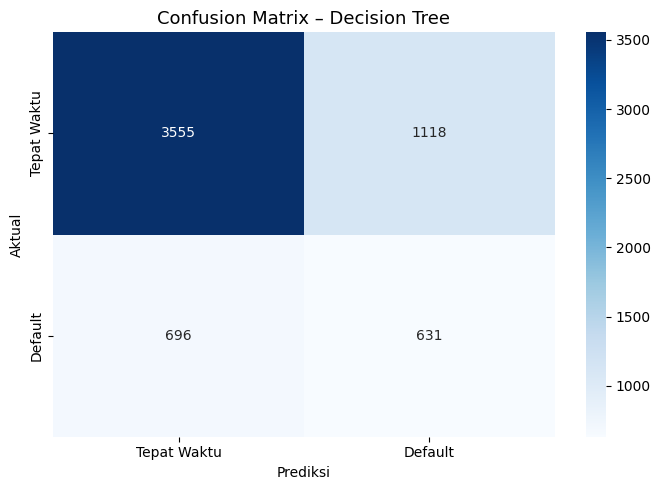

In [ ]:
cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_dt, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Tepat Waktu", "Default"],
            yticklabels=["Tepat Waktu", "Default"])
plt.title("Confusion Matrix – Decision Tree", fontsize=13)
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.tight_layout()
plt.show()

### Visualisasi Decision Tree (Simplified)

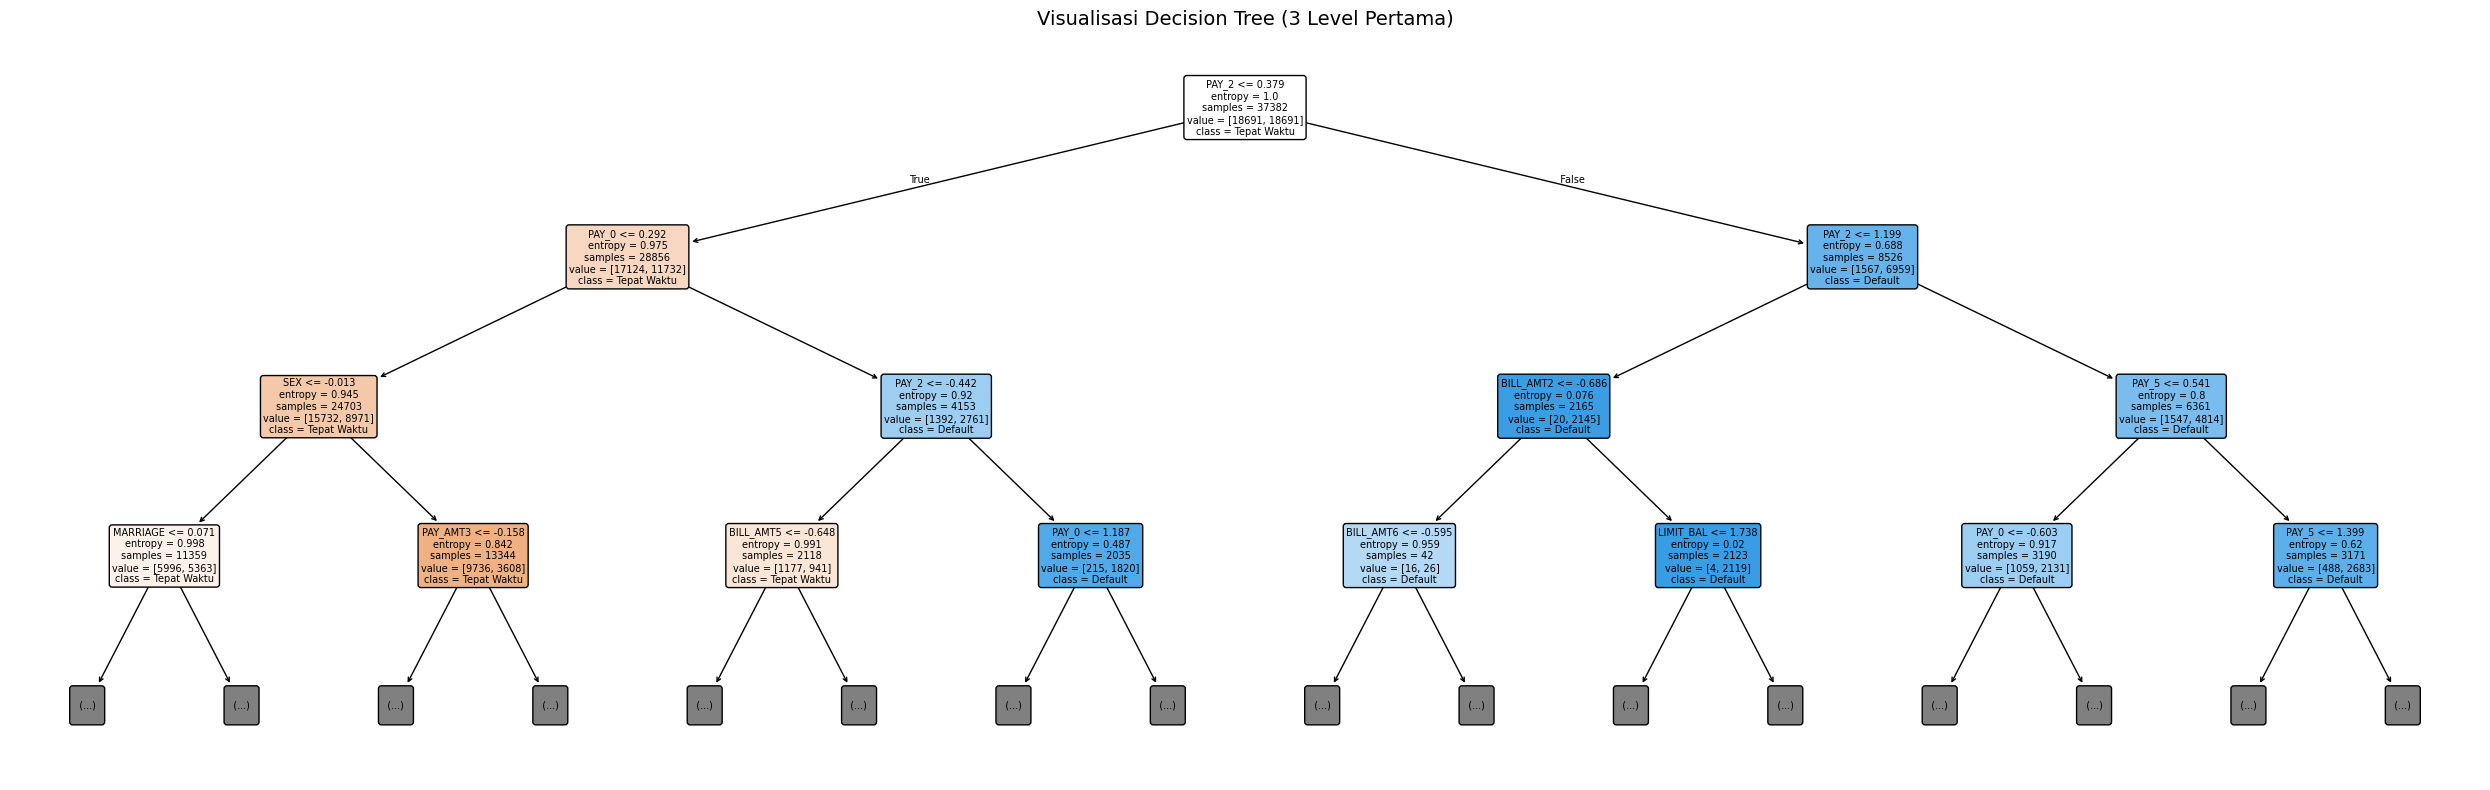

In [ ]:
# Ambil estimator Decision Tree dari dalam pipeline
dt_model_vis = best_dt.named_steps["decisiontreeclassifier"]
scaler_dt_vis = best_dt.named_steps["standardscaler"]
feature_names = X.columns.tolist()

plt.figure(figsize=(25, 8))
plot_tree(
    dt_model_vis,
    feature_names=feature_names,
    class_names=["Tepat Waktu", "Default"],
    filled=True,
    rounded=True,
    fontsize=7,
    max_depth=3  # tampilkan 3 level agar terbaca
)
plt.title("Visualisasi Decision Tree (3 Level Pertama)", fontsize=14)
plt.tight_layout()
plt.show()

### ROC Curve – Decision Tree

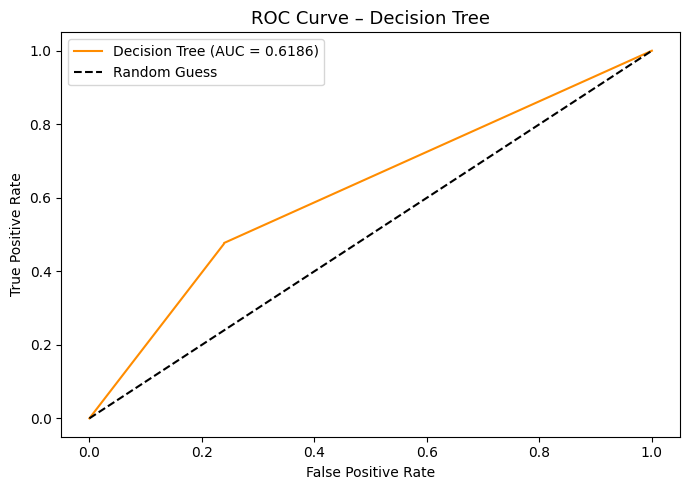

In [ ]:
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)

plt.figure(figsize=(7, 5))
plt.plot(fpr_dt, tpr_dt, color="darkorange",
         label=f"Decision Tree (AUC = {auc_dt:.4f})")
plt.plot([0, 1], [0, 1], "k--", label="Random Guess")
plt.title("ROC Curve – Decision Tree", fontsize=13)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

---
# **Model 3: Artificial Neural Network (ANN/BPNN)**

### ANN Pipeline Creation

In [ ]:
bpnn_pipe = make_pipeline(
    StandardScaler(),
    MLPClassifier(
        hidden_layer_sizes=(64, 32, 16),
        activation="relu",
        solver="adam",
        alpha=0.001,
        max_iter=500,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=15,
        random_state=42
    )
)

bpnn_pipe.fit(X_train, y_train)
print("ANN training selesai!")

ANN training selesai!


### ANN – Evaluasi Model

In [ ]:
y_pred_ann = bpnn_pipe.predict(X_test)
y_prob_ann = bpnn_pipe.predict_proba(X_test)[:, 1]

acc_ann = accuracy_score(y_test, y_pred_ann)
f1_ann  = f1_score(y_test, y_pred_ann)
auc_ann = roc_auc_score(y_test, y_prob_ann)

print("=== Artificial Neural Network – Model Evaluation ===")
print(f"Accuracy  : {acc_ann:.4f}")
print(f"F1-Score  : {f1_ann:.4f}")
print(f"ROC-AUC   : {auc_ann:.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_ann,
      target_names=["Tepat Waktu (0)", "Default (1)"]))

=== Artificial Neural Network – Model Evaluation ===
Accuracy  : 0.7525
F1-Score  : 0.4902
ROC-AUC   : 0.7383
Classification Report:
                 precision    recall  f1-score   support

Tepat Waktu (0)       0.86      0.81      0.84      4673
    Default (1)       0.45      0.54      0.49      1327

       accuracy                           0.75      6000
      macro avg       0.66      0.68      0.66      6000
   weighted avg       0.77      0.75      0.76      6000



### Confusion Matrix – ANN

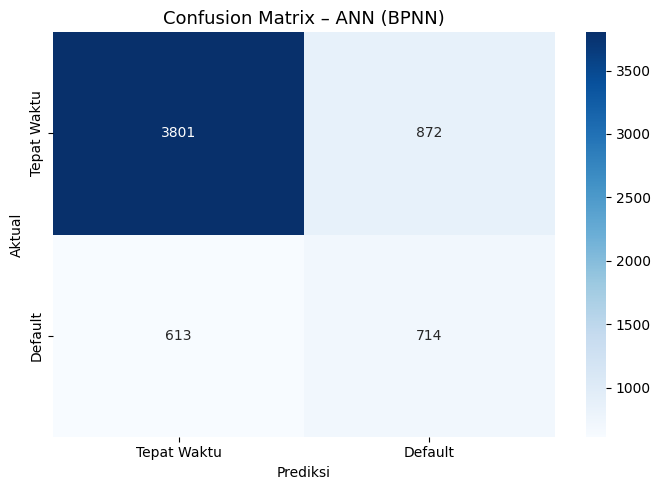

In [ ]:
cm_ann = confusion_matrix(y_test, y_pred_ann)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_ann, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Tepat Waktu", "Default"],
            yticklabels=["Tepat Waktu", "Default"])
plt.title("Confusion Matrix – ANN (BPNN)", fontsize=13)
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.tight_layout()
plt.show()

### ROC Curve – ANN

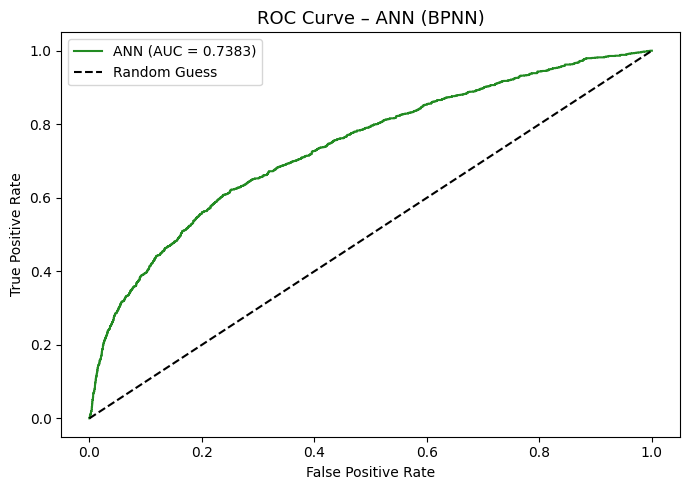

In [ ]:
fpr_ann, tpr_ann, _ = roc_curve(y_test, y_prob_ann)

plt.figure(figsize=(7, 5))
plt.plot(fpr_ann, tpr_ann, color="forestgreen",
         label=f"ANN (AUC = {auc_ann:.4f})")
plt.plot([0, 1], [0, 1], "k--", label="Random Guess")
plt.title("ROC Curve – ANN (BPNN)", fontsize=13)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

---
# **Model Validation**

Validasi model menggunakan 3 metode cross-validation:
- **K-Fold CV** (5 fold)
- **Stratified K-Fold CV** (5 fold)
- **Leave-One-Out CV / LOOCV** (pada sampel 500 data)

### Cross Validation Variables

In [ ]:
kf   = KFold(n_splits=5, shuffle=True, random_state=42)
skf  = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
loocv = LeaveOneOut()

# Gabungkan kembali X_train (post-SMOTE) dan X_test untuk validasi penuh
X_full = np.vstack([X_train, X_test])
y_full = np.concatenate([y_train, y_test])
print(f"Shape data untuk CV (post-SMOTE merge): {X_full.shape}")

# Subset 500 data untuk LOOCV (efisiensi komputasi)
X_loocv = X_full[:500]
y_loocv = y_full[:500]

Shape data untuk CV (post-SMOTE merge): (43382, 23)


### Logistic Regression – Model Validation

In [ ]:
# Logistic Regression dengan pipeline (termasuk scaling)
lr_pipe_val = make_pipeline(
    StandardScaler(),
    LogisticRegression(random_state=42, max_iter=1000,
                       C=grid_search_lr.best_params_["C"],
                       solver=grid_search_lr.best_params_["solver"])
)

cv_lr_kf  = cross_val_score(lr_pipe_val, X_full, y_full, cv=kf,  scoring="accuracy")
cv_lr_skf = cross_val_score(lr_pipe_val, X_full, y_full, cv=skf, scoring="accuracy")
cv_lr_loocv = cross_val_score(lr_pipe_val, X_loocv, y_loocv, cv=loocv, scoring="accuracy")

print("=== Logistic Regression – Cross Validation ===")
print(f"K-Fold Accuracy (5-fold)       : {cv_lr_kf.mean():.4f} (+/- {cv_lr_kf.std():.4f})")
print(f"Stratified K-Fold Accuracy     : {cv_lr_skf.mean():.4f} (+/- {cv_lr_skf.std():.4f})")
print(f"LOOCV Accuracy (Sample 500)    : {cv_lr_loocv.mean():.4f}")

=== Logistic Regression – Cross Validation ===
K-Fold Accuracy (5-fold)       : 0.7264 (+/- 0.0029)
Stratified K-Fold Accuracy     : 0.7263 (+/- 0.0033)
LOOCV Accuracy (Sample 500)    : 0.7940


### Decision Tree – Model Validation

In [ ]:
cv_dt_kf  = cross_val_score(best_dt, X_full, y_full, cv=kf,  scoring="accuracy")
cv_dt_skf = cross_val_score(best_dt, X_full, y_full, cv=skf, scoring="accuracy")
cv_dt_loocv = cross_val_score(best_dt, X_loocv, y_loocv, cv=loocv, scoring="accuracy")

print("=== Decision Tree – Cross Validation ===")
print(f"K-Fold Accuracy (5-fold)       : {cv_dt_kf.mean():.4f} (+/- {cv_dt_kf.std():.4f})")
print(f"Stratified K-Fold Accuracy     : {cv_dt_skf.mean():.4f} (+/- {cv_dt_skf.std():.4f})")
print(f"LOOCV Accuracy (Sample 500)    : {cv_dt_loocv.mean():.4f}")

=== Decision Tree – Cross Validation ===
K-Fold Accuracy (5-fold)       : 0.7508 (+/- 0.0023)
Stratified K-Fold Accuracy     : 0.7511 (+/- 0.0064)
LOOCV Accuracy (Sample 500)    : 0.6920


### ANN – Model Validation

In [ ]:
cv_ann_kf  = cross_val_score(bpnn_pipe, X_full, y_full, cv=kf,  scoring="accuracy")
cv_ann_skf = cross_val_score(bpnn_pipe, X_full, y_full, cv=skf, scoring="accuracy")
cv_ann_loocv = cross_val_score(bpnn_pipe, X_loocv, y_loocv, cv=loocv, scoring="accuracy")

print("=== ANN (BPNN) – Cross Validation ===")
print(f"K-Fold Accuracy (5-fold)       : {cv_ann_kf.mean():.4f} (+/- {cv_ann_kf.std():.4f})")
print(f"Stratified K-Fold Accuracy     : {cv_ann_skf.mean():.4f} (+/- {cv_ann_skf.std():.4f})")
print(f"LOOCV Accuracy (Sample 50)     : {cv_ann_loocv.mean():.4f}")

=== ANN (BPNN) – Cross Validation ===
K-Fold Accuracy (5-fold)       : 0.7738 (+/- 0.0019)
Stratified K-Fold Accuracy     : 0.7733 (+/- 0.0041)
LOOCV Accuracy (Sample 50)     : 0.8080


---
# **Perbandingan Semua Model**

### Tabel Perbandingan Metric (Test Set)

In [ ]:
comparison_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "ANN (BPNN)"],
    "Accuracy":  [acc_lr, acc_dt, acc_ann],
    "F1-Score":  [f1_lr,  f1_dt,  f1_ann],
    "ROC-AUC":   [auc_lr, auc_dt, auc_ann],
    "KFold CV":  [cv_lr_kf.mean(),  cv_dt_kf.mean(),  cv_ann_kf.mean()],
    "StratKFold CV": [cv_lr_skf.mean(), cv_dt_skf.mean(), cv_ann_skf.mean()],
    "LOOCV":     [cv_lr_loocv.mean(), cv_dt_loocv.mean(), cv_ann_loocv.mean()]
})

comparison_df = comparison_df.set_index("Model")
comparison_df = comparison_df.round(4)
print(comparison_df.to_string())
comparison_df

                     Accuracy  F1-Score  ROC-AUC  KFold CV  StratKFold CV  LOOCV
Model                                                                           
Logistic Regression    0.6898    0.4531   0.6914    0.7264         0.7263  0.794
Decision Tree          0.6977    0.4103   0.6186    0.7508         0.7511  0.692
ANN (BPNN)             0.7525    0.4902   0.7383    0.7738         0.7733  0.808


,Accuracy,F1-Score,ROC-AUC,KFold CV,StratKFold CV,LOOCV
Model,,,,,,
Logistic Regression,0.6898,0.4531,0.6914,0.7264,0.7263,0.794
Decision Tree,0.6977,0.4103,0.6186,0.7508,0.7511,0.692
ANN (BPNN),0.7525,0.4902,0.7383,0.7738,0.7733,0.808


### Visualisasi Perbandingan Akurasi Semua Model

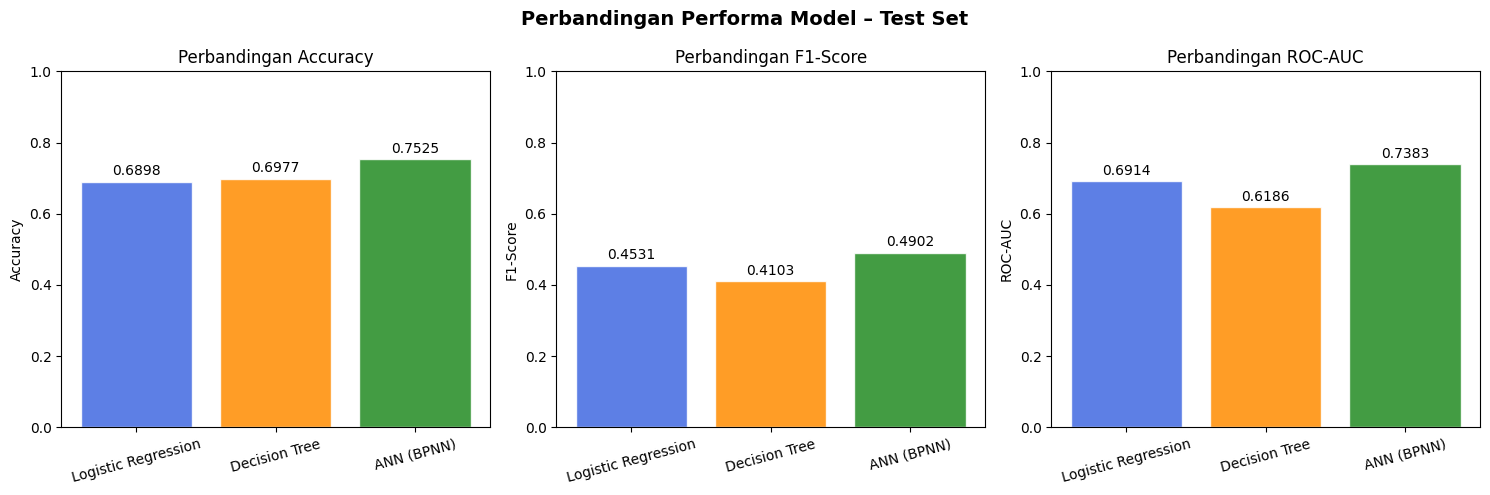

In [ ]:
metrics = ["Accuracy", "F1-Score", "ROC-AUC"]
models  = comparison_df.index.tolist()
colors  = ["royalblue", "darkorange", "forestgreen"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, metric in enumerate(metrics):
    vals = comparison_df[metric].values
    bars = axes[i].bar(models, vals, color=colors, alpha=0.85, edgecolor="white")
    axes[i].set_title(f"Perbandingan {metric}", fontsize=12)
    axes[i].set_ylabel(metric)
    axes[i].set_ylim(0, 1)
    axes[i].tick_params(axis="x", rotation=15)
    for bar, val in zip(bars, vals):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                     f"{val:.4f}", ha="center", va="bottom", fontsize=10)

plt.suptitle("Perbandingan Performa Model – Test Set", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### ROC Curve – Semua Model (Gabungan)

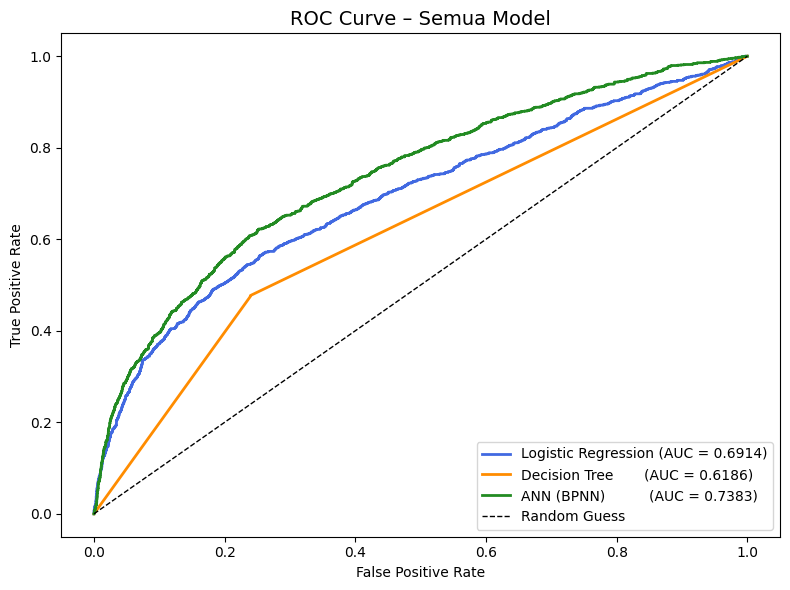

In [ ]:
plt.figure(figsize=(8, 6))
plt.plot(fpr_lr,  tpr_lr,  color="royalblue",   lw=2,
         label=f"Logistic Regression (AUC = {auc_lr:.4f})")
plt.plot(fpr_dt,  tpr_dt,  color="darkorange",   lw=2,
         label=f"Decision Tree       (AUC = {auc_dt:.4f})")
plt.plot(fpr_ann, tpr_ann, color="forestgreen",  lw=2,
         label=f"ANN (BPNN)          (AUC = {auc_ann:.4f})")
plt.plot([0, 1], [0, 1], "k--", lw=1, label="Random Guess")
plt.title("ROC Curve – Semua Model", fontsize=14)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right", fontsize=10)
plt.tight_layout()
plt.show()

### Cross Validation Comparison

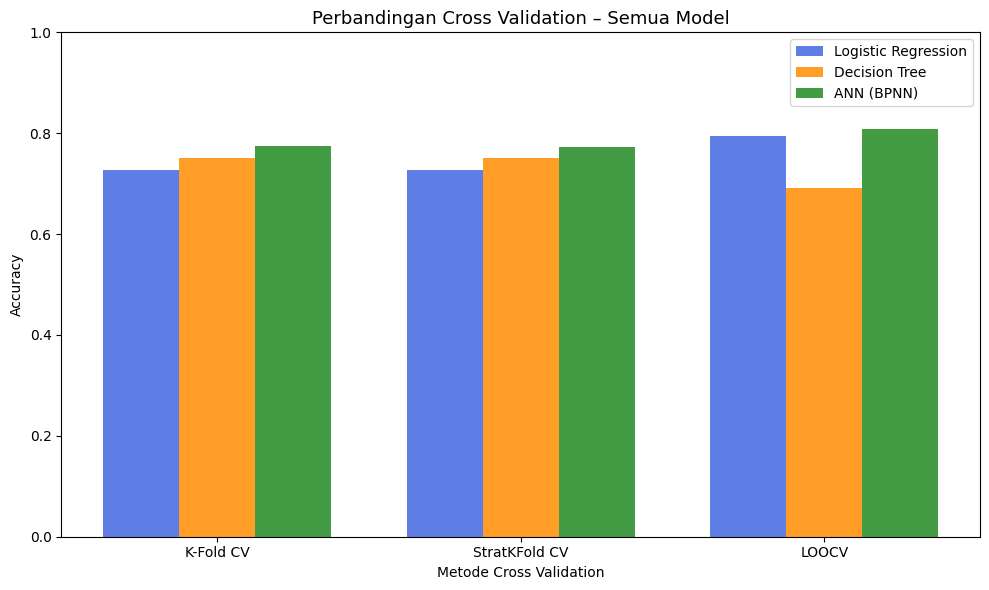

In [ ]:
cv_methods  = ["K-Fold CV", "StratKFold CV", "LOOCV"]
cv_lr_vals  = [cv_lr_kf.mean(),  cv_lr_skf.mean(),  cv_lr_loocv.mean()]
cv_dt_vals  = [cv_dt_kf.mean(),  cv_dt_skf.mean(),  cv_dt_loocv.mean()]
cv_ann_vals = [cv_ann_kf.mean(), cv_ann_skf.mean(), cv_ann_loocv.mean()]

x = np.arange(len(cv_methods))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width, cv_lr_vals,  width, label="Logistic Regression", color="royalblue",  alpha=0.85)
ax.bar(x,         cv_dt_vals,  width, label="Decision Tree",       color="darkorange", alpha=0.85)
ax.bar(x + width, cv_ann_vals, width, label="ANN (BPNN)",          color="forestgreen",alpha=0.85)

ax.set_xlabel("Metode Cross Validation")
ax.set_ylabel("Accuracy")
ax.set_title("Perbandingan Cross Validation – Semua Model", fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(cv_methods)
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.show()

---
# **Kesimpulan**

Berdasarkan evaluasi tiga model klasifikasi terhadap dataset *Default of Credit Card Clients*:

| Model | Kekuatan | Keterbatasan |
|---|---|---|
| **Logistic Regression** | Interpretasi mudah, stabil | Kurang mampu menangkap pola non-linear |
| **Decision Tree** | Sangat interpretatif, visualisasi jelas | Rentan overfitting tanpa pruning |
| **ANN (BPNN)** | Mampu menangkap pola kompleks | Komputasi lebih berat, black-box |

**Rekomendasi Bisnis:**
- Gunakan model terbaik (lihat AUC tertinggi) untuk men-*flag* pelanggan berisiko default sebelum periode tagihan berikutnya.
- Fokuskan strategi retensi dan pemberitahuan awal pada pelanggan dengan probabilitas default > 0.5.
- Fitur paling berpengaruh (berdasarkan Decision Tree) dapat menjadi acuan indikator risiko di sistem CRM perusahaan kartu kredit.